In [1]:
# Standard libraries
import os
import random

# Numerical and Data Processing
import numpy as np  # Linear algebra
import pandas as pd  # Data processing, CSV file I/O (e.g., pd.read_csv)

# PyTorch Data Handling
from torch.utils.data import Dataset, DataLoader
from models.clip_based_unet import CLIPResnetSegmentationModel
# OpenCV for image processing
import cv2

# Visualization
import matplotlib.pyplot as plt
%matplotlib inline

# Custom utilities and configuration
from utils import visualize, analyze
from data_providers import test_dataset,val_dataset,train_dataset
from config import PATH_TEST, PATH_TRAINVAL, SEED, BATCH_SIZE

# NN Framework
import torch
from models.unet_model import UNet
import torchviz

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Set random seed for reproducibility
random.seed(SEED)


test_image_path = os.path.join(PATH_TEST, 'color/')
test_mask_path = os.path.join(PATH_TEST, 'label/')
test_image_list_orig = sorted(os.listdir(test_image_path))
test_mask_list_orig = sorted(os.listdir(test_mask_path))

trainval_image_path = os.path.join(PATH_TRAINVAL, 'color/')
trainval_mask_path = os.path.join(PATH_TRAINVAL, 'label/')
trainval_image_list_orig = sorted(os.listdir(trainval_image_path))
trainval_mask_list_orig = sorted(os.listdir(trainval_mask_path))
image_list = [trainval_image_path+i for i in trainval_image_list_orig]
mask_list = [trainval_mask_path+i for i in trainval_mask_list_orig]
len(trainval_mask_list_orig)

3680

# 0. Image samples Visualization

In [2]:
N = 90

image = cv2.imread(image_list[N])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
mask = cv2.imread(mask_list[N], cv2.IMREAD_UNCHANGED)
mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

analyze(image, mask)
print(image_list[N],"\n",mask_list[N])

N = 190

image = cv2.imread(image_list[N])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
mask = cv2.imread(mask_list[N], cv2.IMREAD_UNCHANGED)
mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

analyze(image, mask)
print(image_list[N],"\n",mask_list[N])

Dataset/TrainVal/color/Abyssinian_184.jpg 
 Dataset/TrainVal/label/Abyssinian_184.png


Dataset/TrainVal/color/Bengal_182.jpg 
 Dataset/TrainVal/label/Bengal_182.png


# Image Input

# 1.  Dataset preprocessing and augmentation

In [3]:


# Create DataLoaders
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Example: Fetch a batch
images, masks = next(iter(train_dataloader))
print(f"Image batch shape: {images.shape}, Mask batch shape: {masks.shape}")


Image batch shape: torch.Size([4, 3, 224, 224]), Mask batch shape: torch.Size([4, 224, 224])


/Users/erikasalinasgonzalez/Documents/Master AI/CV/coursework/U-Net-Segmentation/data_input.py:98: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).



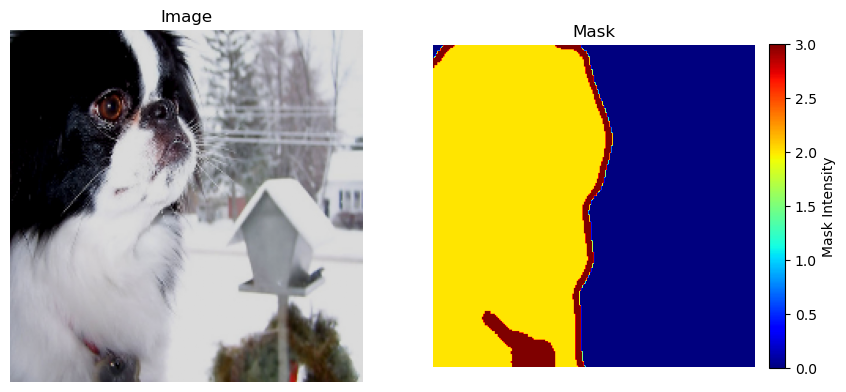

Image shape:  torch.Size([3, 224, 224])


In [4]:
N=random.randint(0,BATCH_SIZE-1)
visualize(images[N].permute(1, 2, 0).numpy(),masks[N])
print("Image shape: ",images[N].shape)

# 2. Segmentation network design and implementation

### 2.a) UNet design and output verification

In [5]:
from model import UNet

model = UNet(input_channels=3, n_filters=64,  n_classes=4)
output = model(images)
print(output.shape)  


torch.Size([4, 4, 224, 224])


##### Output Dimention Verification

Mask shape:  torch.Size([4, 224, 224])


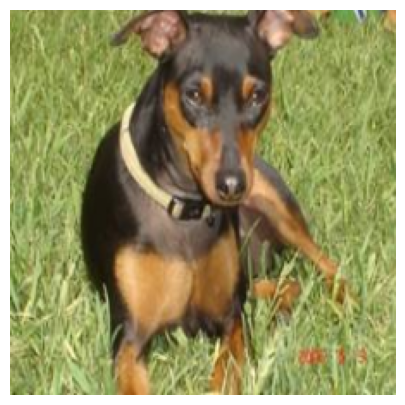

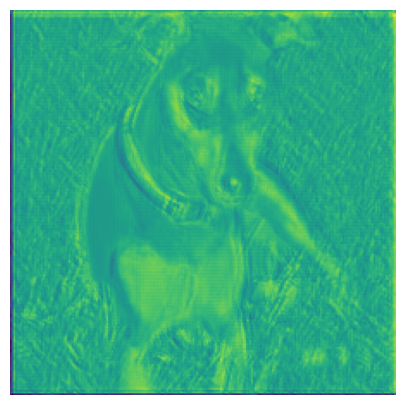

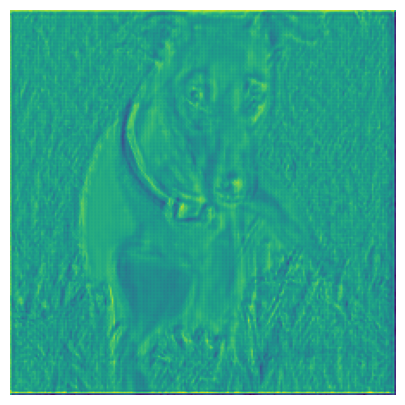

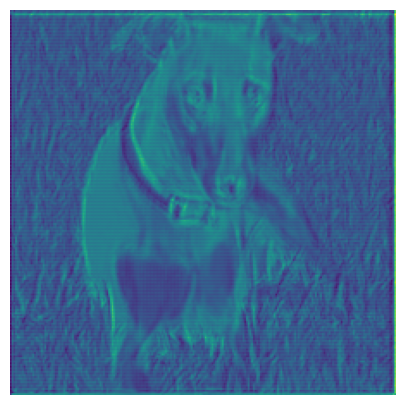

In [6]:
print("Mask shape: ",output[N].shape)
visualize(images[N].permute(1, 2, 0).detach().numpy())
visualize(output[N][0].detach().numpy())
visualize(output[N][1].detach().numpy())
visualize(output[N][2].detach().numpy())



##### The model architecture

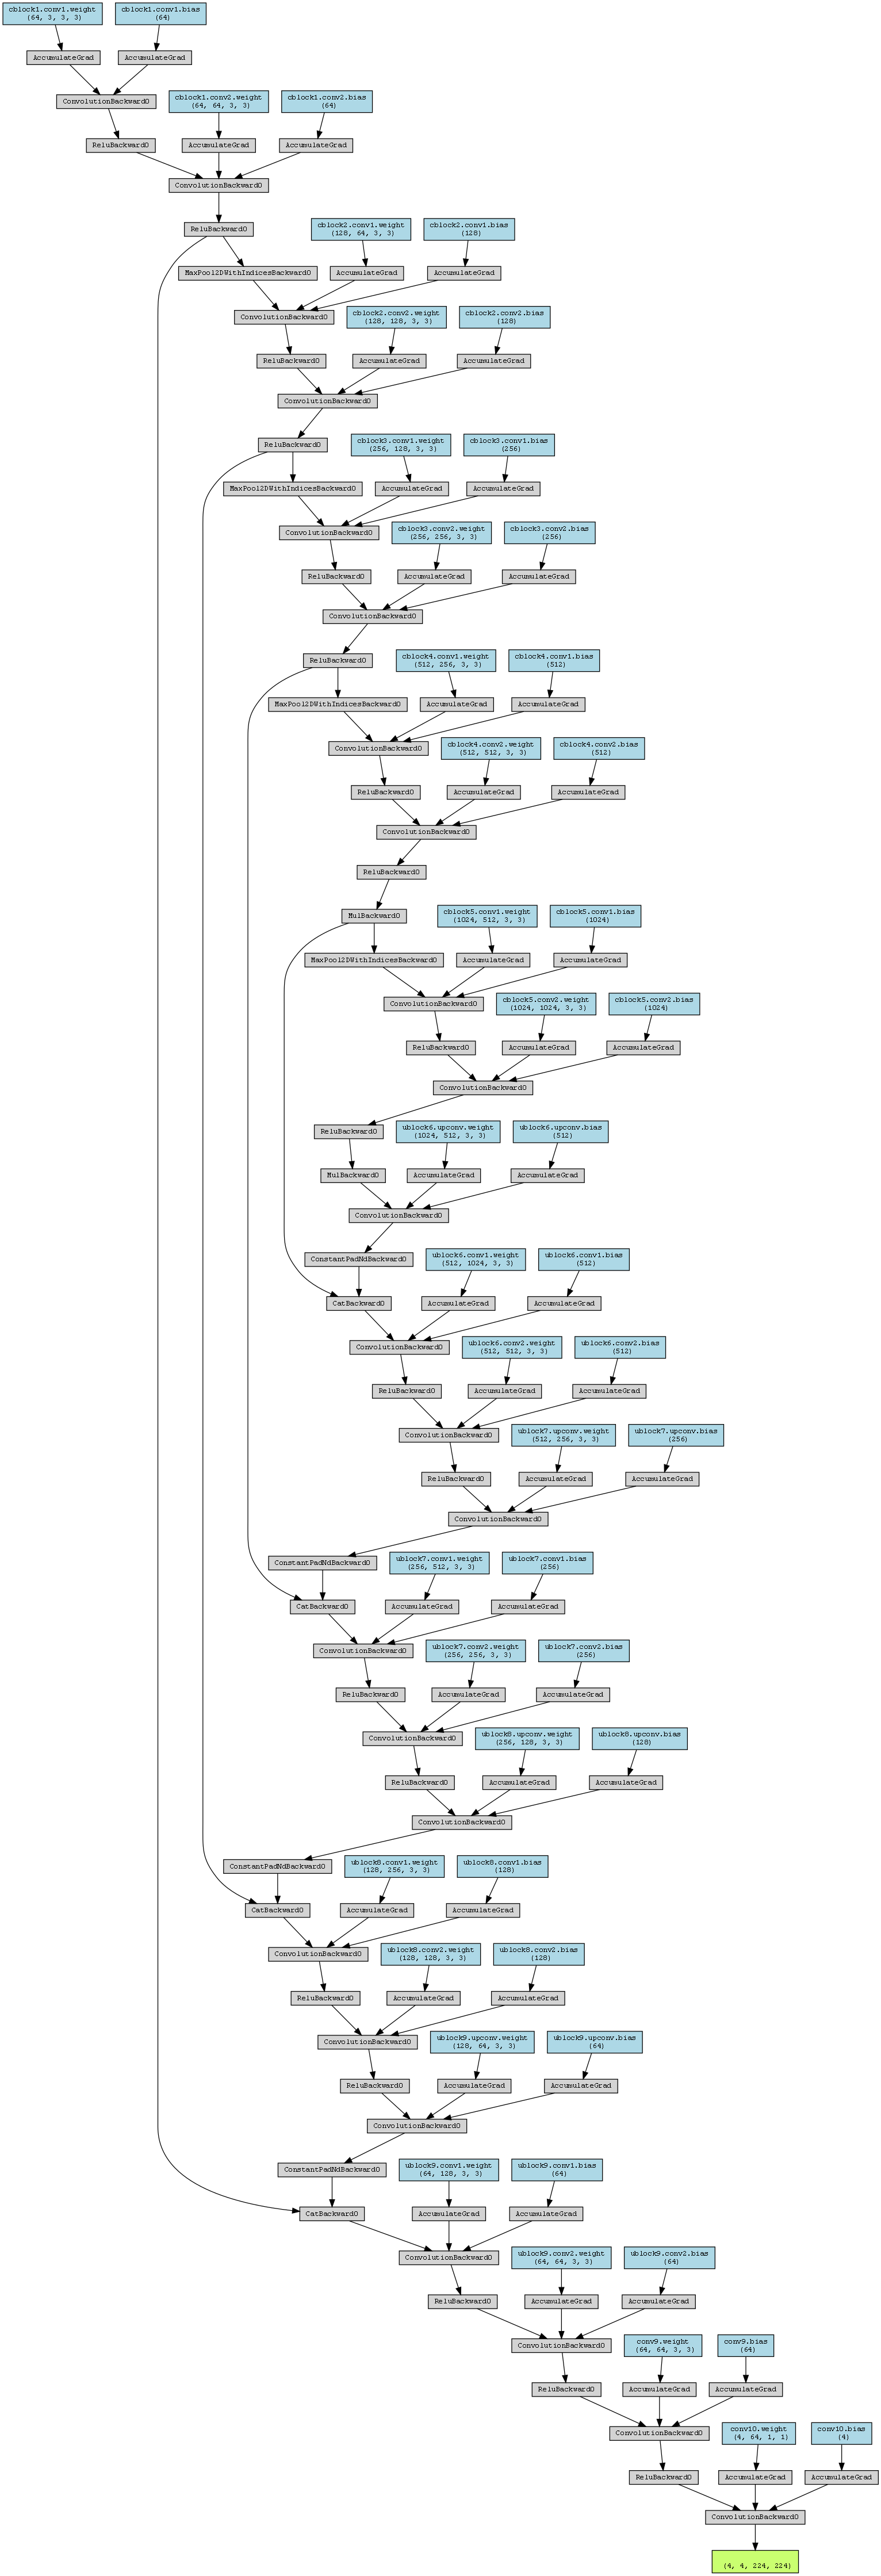

In [7]:
dot = torchviz.make_dot(output, params=dict(model.named_parameters()))
dot.format = 'png'
dot.render("nn_graph")
from IPython.display import Image
Image("nn_graph.png")

### 2.b) Autoencoder pre-training

In [8]:
from model import Autoencoder
import torch.optim as optim
import torch.nn as nn

retrain = False

# Hyperparameters
epochs = 20
learning_rate = 0.0001


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
autoencoder = Autoencoder(input_channels=3, n_filters=64).to(device)
autoencoder.load_state_dict(torch.load("weights/autoencoder/autoencoder_weights_0.002858656363969203.pth", map_location=device))
optimizer = optim.Adam(autoencoder.parameters(), lr=learning_rate)
criterion = nn.MSELoss()

if retrain:
    min_loss = 1000
    # Training loop
    for epoch in range(epochs):
        autoencoder.train()
        total_loss = 0

        for images, _ in train_dataloader:  # Ignore masks
            images = images.to(device)

            # Forward pass
            outputs = autoencoder(images)
            loss = criterion(outputs, images)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
        avg_loss = total_loss/len(train_dataloader)
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.6f}")
        if avg_loss < min_loss:
            min_loss = avg_loss
            torch.save(autoencoder.state_dict(), f"weights/autoencoder_weights_{min_loss}.pth")
            print("Model saved.")


##### Testing Autoencoder's Output

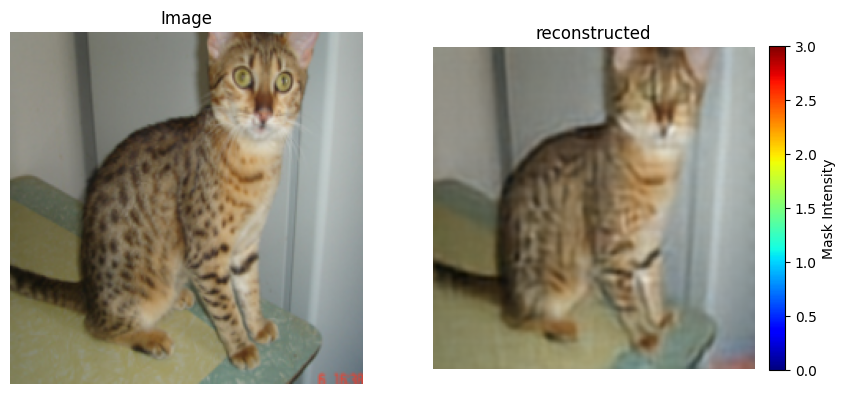

Image shape:  torch.Size([3, 224, 224])
Reconstructed shape:  torch.Size([3, 224, 224])


In [9]:
images, masks = next(iter(val_dataloader))
N=random.randint(0,BATCH_SIZE-1)

autoencoder.eval()
with torch.no_grad():
    reconstructed = autoencoder(images[N])


visualize(images[N].permute(1, 2, 0).numpy(),reconstructed.permute(1, 2, 0).numpy(),"reconstructed")
print("Image shape: ",images[N].shape)
print("Reconstructed shape: ",reconstructed.shape)

##### Leveraging Autoencoder's weights to train segmentation

In [10]:
from model import Autoencoder,UNet
import torch.optim as optim
import torch.nn as nn
autoencoder_weights = torch.load("weights/autoencoder/autoencoder_weights_0.002858656363969203.pth", map_location=device)


autoencoder = Autoencoder(input_channels=3, n_filters=64)
autoencoder.load_state_dict(autoencoder_weights, strict=False)

unet = UNet(input_channels=3, n_filters=64, n_classes=4)
# Copy encoder weights from Autoencoder to U-Net
unet.cblock1.load_state_dict(autoencoder.cblock1.state_dict())
unet.cblock2.load_state_dict(autoencoder.cblock2.state_dict())
unet.cblock3.load_state_dict(autoencoder.cblock3.state_dict())
unet.cblock4.load_state_dict(autoencoder.cblock4.state_dict())
unet.cblock5.load_state_dict(autoencoder.cblock5.state_dict())

print("Encoder weights successfully transferred from Autoencoder to U-Net!")

for param in [unet.cblock1.parameters(), unet.cblock2.parameters(),
              unet.cblock3.parameters(), unet.cblock4.parameters(),
              unet.cblock5.parameters()]:
    for p in param:
        p.requires_grad = False

print("Encoder frozen for fine-tuning U-Net!")

Encoder weights successfully transferred from Autoencoder to U-Net!
Encoder frozen for fine-tuning U-Net!


In [ ]:
# Define training parameters
retrain = False
epochs = 10
learning_rate = 0.001
batch_size = 8  # Adjust based on your GPU memory
best_val_loss = float("inf")

# Move model to GPU (if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
unet.to(device)

# Define DataLoaders
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Define Loss and Optimizer
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, unet.parameters()), lr=learning_rate)
criterion = torch.nn.CrossEntropyLoss()

if retrain:
    print("Training U-Net for segmentation...")
    for epoch in range(epochs):
        # ---------------------------
        # Training Phase
        # ---------------------------
        unet.train()
        train_loss = 0
        for images, masks in train_dataloader:
            images, masks = images.to(device), masks.to(device)

            # Forward pass
            outputs = unet(images)
            loss = criterion(outputs, masks)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_dataloader)

        # ---------------------------
        # Validation Phase
        # ---------------------------
        unet.eval()
        val_loss = 0
        with torch.no_grad():
            for images, masks in val_dataloader:
                images, masks = images.to(device), masks.to(device)

                outputs = unet(images)
                loss = criterion(outputs, masks)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_dataloader)

        # Print loss for this epoch
        print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}")

        # Save the best model based on validation loss
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(unet.state_dict(), f"weights/autoencoder/autoencoder_unet/unet_best_{best_val_loss:.4f}.pth")
            print("Best model saved!")

print("Training complete!")


Training complete!


##### Testing Autoencoder-pretrained UNet's Output

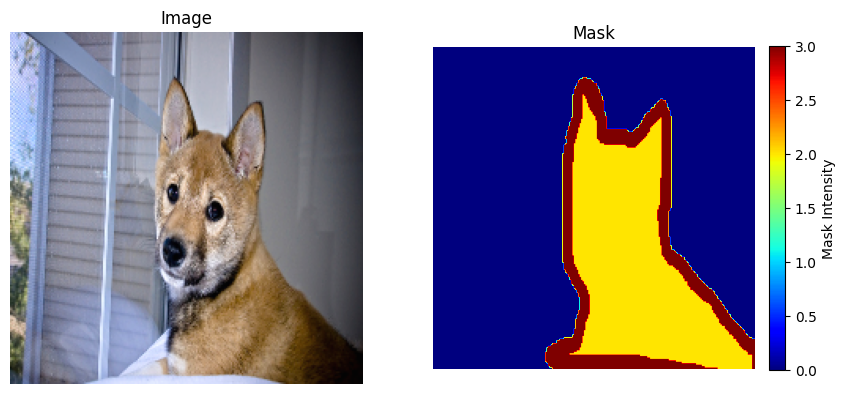

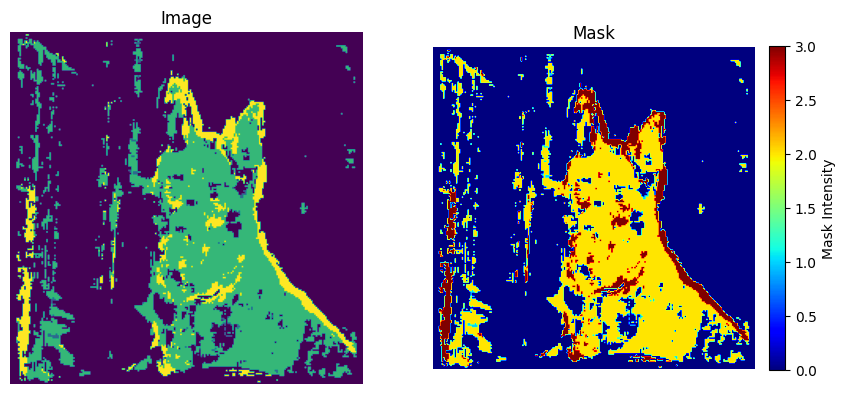

In [52]:
unet = UNet(input_channels=3, n_filters=64).to(device)
unet.load_state_dict(torch.load("weights/autoencoder/autoencoder_unet/unet_best_0.9319.pth", map_location=device))

images, masks = next(iter(val_dataloader))
images, masks = images.to(device), masks.to(device)
N=0#random.randint(0,BATCH_SIZE-1)
mask = masks[N].cpu().numpy()
unet.eval()
with torch.no_grad():
    logits = unet(images)  # Output shape: (B, n_classes, H, W)
    predicted_classes = torch.argmax(logits, dim=1)  # Shape: (B, H, W)

    # Convert to NumPy for visualization (assuming batch index N)
    segmentation_mask = predicted_classes[N].cpu().numpy()  # Shape: (H, W)

    # Directly use segmentation_mask instead of recomputing it
    composite = segmentation_mask  # Already contains class indices 0,1,2,3

# Visualize the original image and the predicted segmentation mask
visualize(images[N].permute(1, 2, 0).cpu().numpy(), mask)
visualize(composite, composite)  # This line is redundant but should work fine

# print("Image shape: ",images[N].shape)
# print("masks shape: ",masks[N].shape)
# print("probabilities shape: ",probabilities[N].shape)

### 2.c) CLIP Features fir segmentation

In [2]:
df = pd.read_csv("CLIP_CLIP_experiment/result_outputs/summary.csv")

In [3]:
best_epoch = df[df.val_iou == df.val_iou.max()]

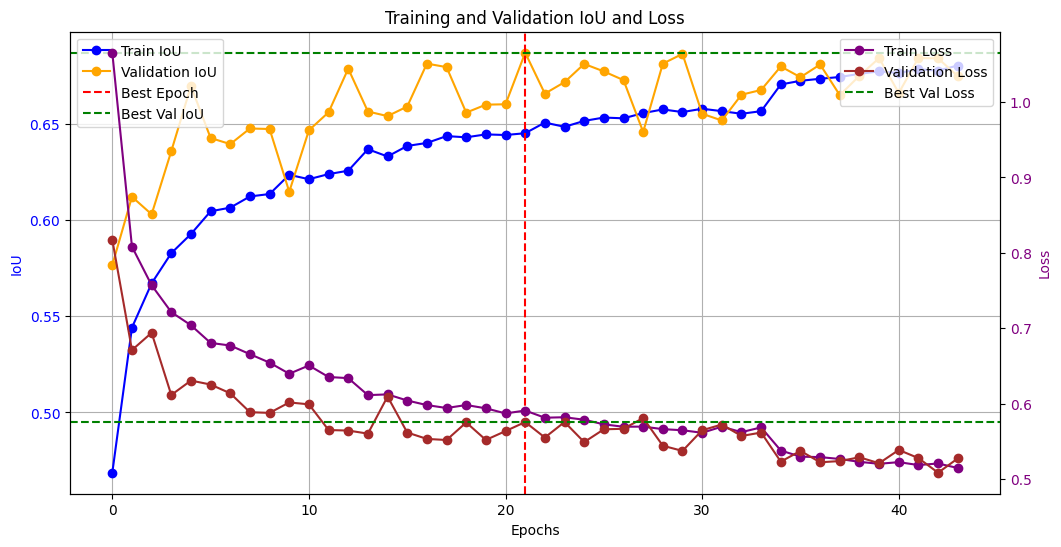

In [4]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot IoU on the primary y-axis
ax1.plot(df.index, df['train_iou'], label='Train IoU', marker='o', color='blue')
ax1.plot(df.index, df['val_iou'], label='Validation IoU', marker='o', color='orange')
ax1.axvline(x=best_epoch.index[0], color='red', linestyle='--', label='Best Epoch')
ax1.axhline(y=best_epoch.val_iou.values[0], color='green', linestyle='--', label='Best Val IoU')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('IoU', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.legend(loc='upper left')
ax1.grid(True)

# Plot Loss on the secondary y-axis
ax2 = ax1.twinx()
ax2.plot(df.index, df['train_loss'], label='Train Loss', marker='o', color='purple')
ax2.plot(df.index, df['val_loss'], label='Validation Loss', marker='o', color='brown')
ax2.axhline(y=best_epoch.val_loss.values[0], color='green', linestyle='--', label='Best Val Loss')
ax2.set_ylabel('Loss', color='purple')
ax2.tick_params(axis='y', labelcolor='purple')
ax2.legend(loc='upper right')

plt.title('Training and Validation IoU and Loss')
plt.show()

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instantiate model
nn_model = CLIPResnetSegmentationModel(device, n_classes=4).to(device)

# Load trained weights
checkpoint = torch.load("CLIP_CLIP_experiment/saved_models/train_model_21", map_location=device)
print(checkpoint.keys())  # Should contain something like 'network', 'optimizer', etc.
print(checkpoint["network"].keys())  # See if names start with 'module.' or not

from collections import OrderedDict

# Get the saved state dict
saved_state_dict = checkpoint["network"]

model_dict = nn_model.state_dict()
decoder_weights = {k.replace("model.", "", 1): v for k, v in saved_state_dict.items() if "decoder" in k}
model_dict.update(decoder_weights)
nn_model.load_state_dict(model_dict)


C:\Users\jorge\AppData\Local\Temp\ipykernel_9564\4225686464.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("CLIP_CLIP_experiment/saved_models/tr

dict_keys(['model_epoch', 'network', 'best_val_model_idx', 'best_val_model_acc'])
odict_keys(['model.encoder.clip_encoder.conv1.weight', 'model.encoder.clip_encoder.bn1.weight', 'model.encoder.clip_encoder.bn1.bias', 'model.encoder.clip_encoder.bn1.running_mean', 'model.encoder.clip_encoder.bn1.running_var', 'model.encoder.clip_encoder.bn1.num_batches_tracked', 'model.encoder.clip_encoder.conv2.weight', 'model.encoder.clip_encoder.bn2.weight', 'model.encoder.clip_encoder.bn2.bias', 'model.encoder.clip_encoder.bn2.running_mean', 'model.encoder.clip_encoder.bn2.running_var', 'model.encoder.clip_encoder.bn2.num_batches_tracked', 'model.encoder.clip_encoder.conv3.weight', 'model.encoder.clip_encoder.bn3.weight', 'model.encoder.clip_encoder.bn3.bias', 'model.encoder.clip_encoder.bn3.running_mean', 'model.encoder.clip_encoder.bn3.running_var', 'model.encoder.clip_encoder.bn3.num_batches_tracked', 'model.encoder.clip_encoder.layer1.0.conv1.weight', 'model.encoder.clip_encoder.layer1.0.bn1.wei

<All keys matched successfully>

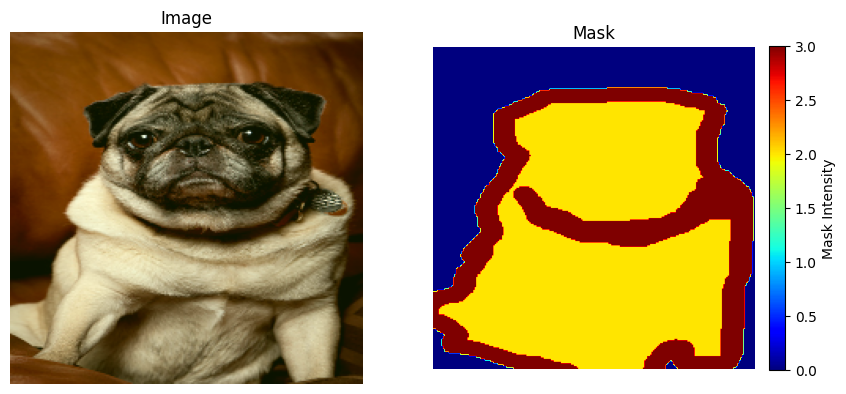

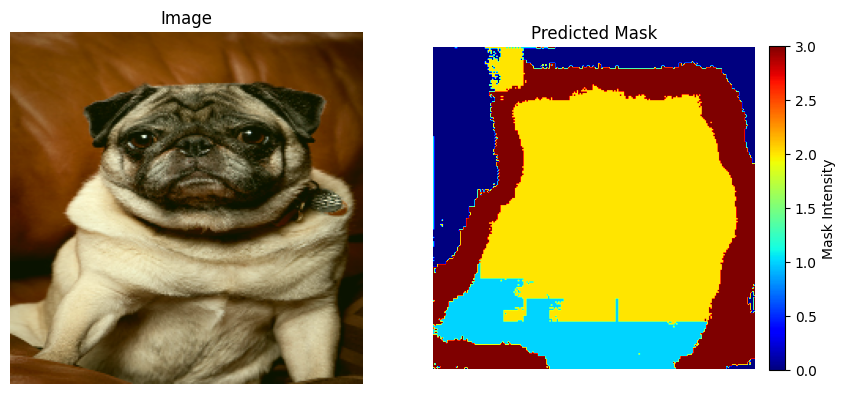

In [24]:
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)


images, masks = next(iter(test_dataloader))
images, masks = images.to(device), masks.to(device)
N = random.randint(0,BATCH_SIZE-1)
mask = masks[N].cpu().numpy()
nn_model.eval()
with torch.no_grad():
    logits = nn_model(images)  # Output shape: (B, n_classes, H, W)
    predicted_classes = torch.argmax(logits, dim=1)  # Shape: (B, H, W)

    # Convert to NumPy for visualization (assuming batch index N)
    segmentation_mask = predicted_classes[N].cpu().numpy()  # Shape: (H, W)

    # Directly use segmentation_mask instead of recomputing it
    composite = segmentation_mask  # Already contains class indices 0,1,2,3

# Visualize the original image and the predicted segmentation mask
visualize(images[N].permute(1, 2, 0).cpu().numpy(), mask)
visualize(images[N].permute(1, 2, 0).cpu().numpy(), composite,"Predicted Mask")  # This line is redundant but should work fine

### 2.d) Prompt-based segmentation

##### New Dataset Generation